Data taken from:
https://www.kaggle.com/datasets/xvivancos/star-wars-movie-scripts

In [29]:
# import bpe library

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [30]:
# create tokenizer & set files & train

bpe_tokenizer = Tokenizer(BPE())

# used to break down into words before tokenizing, can be turned off
bpe_tokenizer.pre_tokenizer = Whitespace() 

bpe_trainer = BpeTrainer(vocab_size=1000)
files = ['episodeIV_cleaned.txt','episodeV_cleaned.txt','episodeVI_cleaned.txt']

# train file
bpe_tokenizer.train(files, bpe_trainer)


In [31]:
# make things pretty to output
from colorama import Fore, Style

def pretty_print_token_and_ids(tokenized):
    colors = [Fore.RED, Fore.GREEN, Fore.YELLOW, Fore.BLUE, Fore.MAGENTA, Fore.CYAN]
    for i, (tok, idx) in enumerate(zip(tokenized.tokens, tokenized.ids)):
        color = colors[i % len(colors)]
        print(f"{color}{tok} ({idx}){Style.RESET_ALL}", end=" ")

def pretty_print_tokens(tokenized):
    colors = [Fore.RED, Fore.GREEN, Fore.YELLOW, Fore.BLUE, Fore.MAGENTA, Fore.CYAN]
    for i, (tok, idx) in enumerate(zip(tokenized.tokens, tokenized.ids)):
        color = colors[i % len(colors)]
        print(f"{color}{tok}{Style.RESET_ALL}", end=" ")

In [32]:
# print and toy with results



bpe_output = bpe_tokenizer.encode("now what in the tarnation Vader? where did that lightsaber come from?")
pretty_print_tokens(bpe_output)

# not as pretty printing
# print(bpe_output.tokens)



now what in the t ar n ation Vader ? where did that light s ab er come from ? 

### Weird discovery: 
When printing out the tokenization of lightsaber by using BPE encoding and a vocab size of 1000, we noticed that "lightsaber" was broken down into `['light', 's', 'ab', 'er']`

Trying `[cntr]+F` we found that there are only 4 times the word is spoken in the original Star Wars trilogy: once in Episode IV and three times in Episode VI.

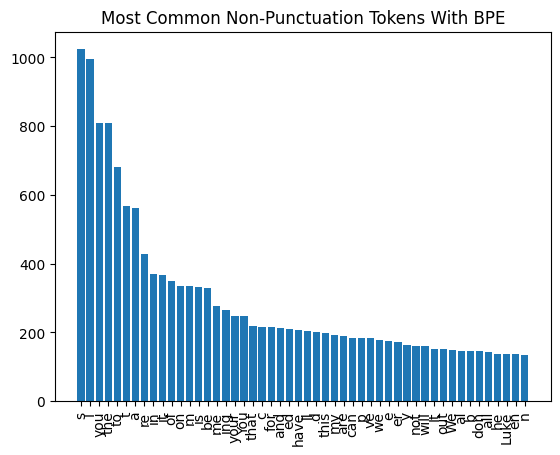

In [35]:
from collections import Counter
import matplotlib.pyplot as plt
import re

all_tokens = []
for ep_num in ['IV','V','VI']:
    with open(f'episode{ep_num}_cleaned.txt') as f:
        for line in f:
            enc = bpe_tokenizer.encode(line.strip())
            all_tokens.extend(enc.tokens)

word_tokens = [t for t in all_tokens if re.search(r'\w', t)]

counts = Counter(word_tokens).most_common(50)
tokens, freqs = zip(*counts)

plt.bar(tokens,freqs)
plt.xticks(rotation=90)
plt.title("Most Common Non-Punctuation Tokens With BPE")
plt.show()
